<a href="https://colab.research.google.com/github/AfzalNavas/northstar-analytics/blob/main/notebooks/SQL_IN_R_SECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages("sqldf")
install.packages("tidyverse")
install.packages("RCurl")

library(sqldf)
library(tidyverse)
library(RCurl)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
deliveries <- read.csv("https://raw.githubusercontent.com/AfzalNavas/northstar-analytics/refs/heads/main/data/deliveries.csv")
complaints <- read.csv("https://raw.githubusercontent.com/AfzalNavas/northstar-analytics/refs/heads/main/data/complaints.csv")
customers  <- read.csv("https://raw.githubusercontent.com/AfzalNavas/northstar-analytics/refs/heads/main/data/customers.csv")
orders     <- read.csv("https://raw.githubusercontent.com/AfzalNavas/northstar-analytics/refs/heads/main/data/orders.csv")

# A tibble: 7 × 3
  complaint_type    total_complaints avg_resolution_days
  <chr>                        <int>               <dbl>
1 Delay                          101                7.26
2 MissedPickup                    64                7.64
3 AppIssue                        53                8.6 
4 DriverBehaviour                 51                8.16
5 SupportExperience               20                7.45
6 Billing                         16                7.75
7 Damage                          15               11.3 


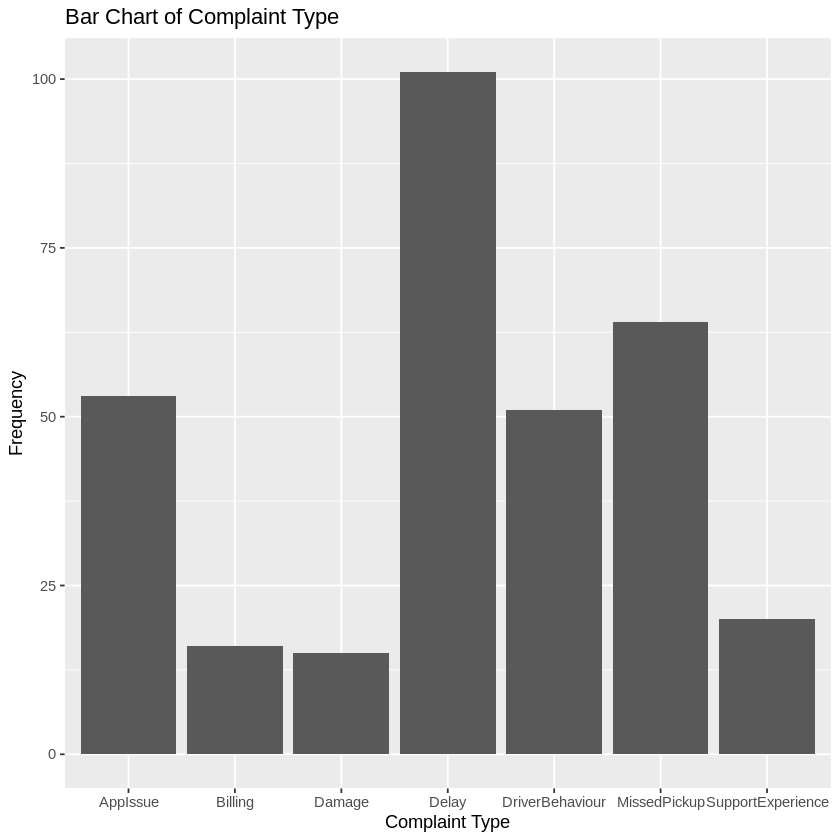

In [ ]:
case1 <- sqldf("SELECT complaint_type,
    COUNT(complaint_id) AS total_complaints,
    ROUND(AVG(resolution_days), 2) AS avg_resolution_days
  FROM complaints GROUP BY complaint_type ORDER BY total_complaints DESC")

print(as_tibble(case1))

ggplot(complaints, aes(x = factor(complaint_type))) + geom_bar() +
  labs(title = "Bar Chart of Complaint Type", x = "Complaint Type", y = "Frequency")

# A tibble: 7 × 2
  pickup_zone total_compensation
  <chr>                    <dbl>
1 Central                  1256.
2 North                    1123.
3 East                     1012.
4 Riverside                 825.
5 South                     768.
6 West                      730.
7 Airport                   445.


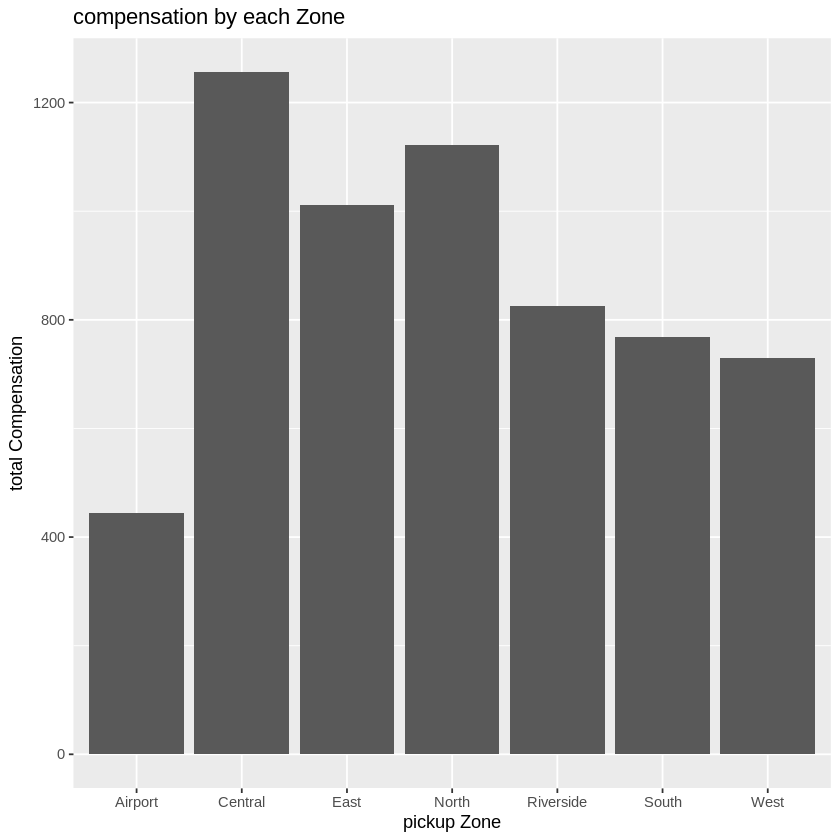

In [ ]:
case2 <- sqldf("
  SELECT o.pickup_zone,
  ROUND(SUM(COALESCE(co.compensation_amount, 0)), 2) as total_compensation
  FROM complaints co
  LEFT JOIN orders o ON co.order_id = o.order_id
  WHERE o.pickup_zone IS NOT NULL GROUP BY o.pickup_zone ORDER BY total_compensation DESC
")
print(as_tibble(case2))

ggplot(case2, aes(x = factor(pickup_zone), y = total_compensation)) + geom_bar(stat = "identity") +
  labs(title = "compensation by each Zone", x = "pickup Zone", y = "total Compensation")

[1] "the total number of repeat complainers:"
[1] 74


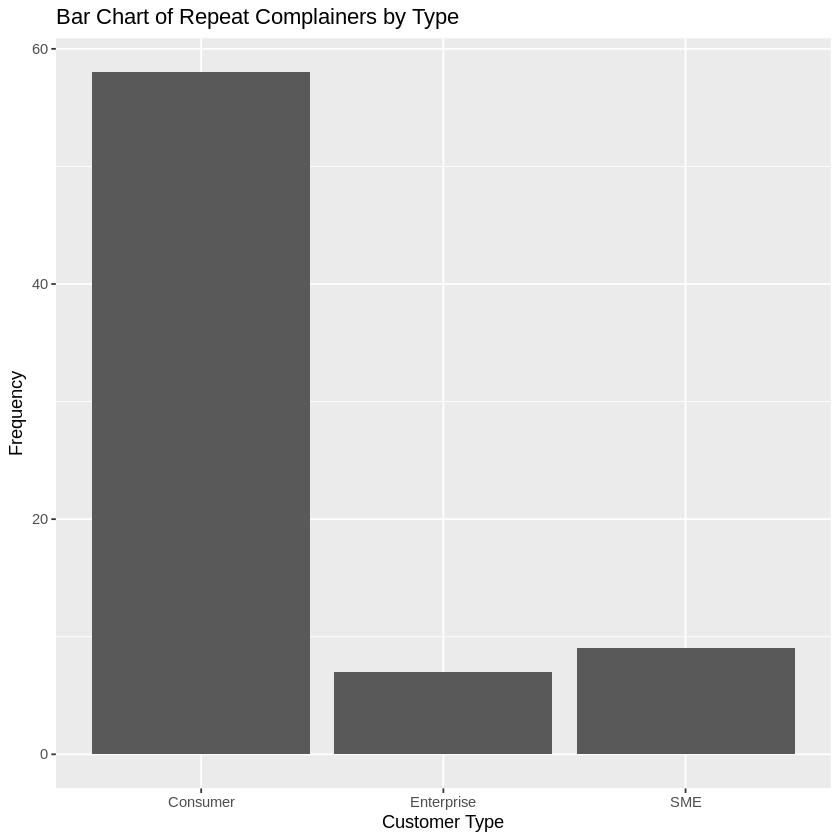

In [ ]:
case3 <- sqldf("
  SELECT
  co.customer_id,
  cu.customer_type,
  COUNT(co.complaint_id) as complaint_count
  FROM complaints co
  LEFT JOIN customers cu ON co.customer_id = cu.customer_id
  GROUP BY co.customer_id, cu.customer_type HAVING complaint_count > 1
")
print("the total number of repeat complainers:")
print(nrow(case3))

case3_summary <- sqldf("
  SELECT customer_type, COUNT(customer_id) as repeat_complainers
  FROM case3 GROUP BY customer_type")

ggplot(case3_summary, aes(x = factor(customer_type), y = repeat_complainers)) + geom_bar(stat = "identity") +
  labs(title = "Bar Chart of Repeat Complainers by Type", x = "Customer Type", y = "Frequency")

[1] "total complaints on orders that are marked OnTime:"
[1] 149
[1] "the missing proof of completion:"
[1] 0
[1] 0


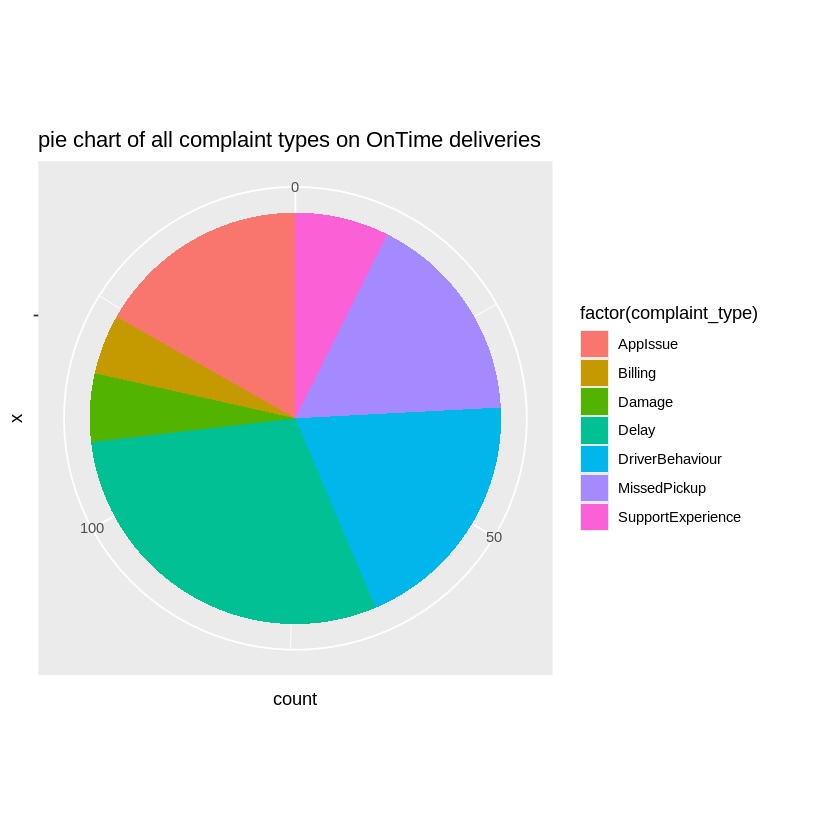

In [ ]:
case4 <- sqldf("
  SELECT
  co.complaint_id,
  co.complaint_type,
  d.delivery_status,
  d.proof_of_completion_missing
  FROM complaints co
  LEFT JOIN deliveries d ON co.order_id = d.order_id
  WHERE d.delivery_status = 'OnTime'
")

print("total complaints on orders that are marked OnTime:")
print(nrow(case4))
print("the missing proof of completion:")
print(sum(case4$proof_of_completion_missing %in% c("True", "TRUE", 1, TRUE), na.rm=TRUE))
print(unique(case4$proof_of_completion_missing))

case4_breakdown <- sqldf("
  SELECT complaint_type, COUNT(*) as count
  FROM case4 GROUP BY complaint_type
")

case4_breakdown %>%
  ggplot(aes(x = "", y = count, fill = factor(complaint_type))) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  labs(title = "pie chart of all complaint types on OnTime deliveries")

# A tibble: 4 × 3
  channel total_complaints escalated_cases
  <chr>              <int>           <int>
1 App                   97              11
2 Chatbot               67               6
3 Email                 64              11
4 Phone                 92              10


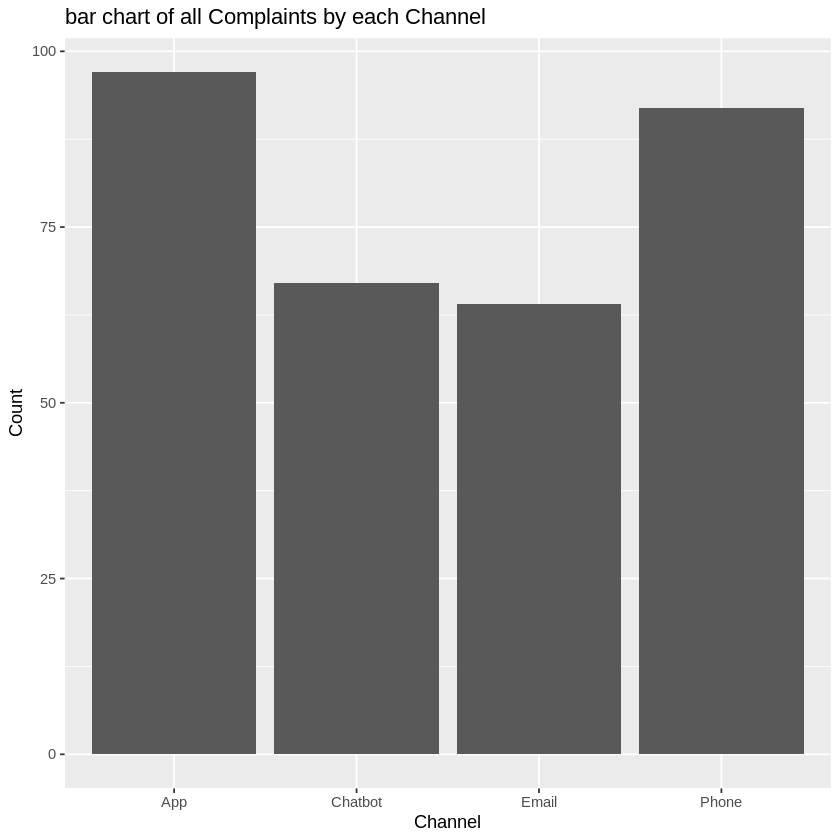

In [ ]:
case5 <- sqldf("
  SELECT
  channel,
  COUNT(complaint_id) as total_complaints,
  SUM(CASE WHEN status = 'Escalated' THEN 1 ELSE 0 END) as escalated_cases
  FROM complaints GROUP BY channel
")
print(as_tibble(case5))

ggplot(case5, aes(x = factor(channel), y = total_complaints)) + geom_bar(stat = "identity") +
  labs(title = "bar chart of all Complaints by each Channel", x = "Channel", y = "Count")

In [ ]:
final_findings_summary <- tibble(
  Finding = c(
    "most frequent of complaint by type",
    "the highest zone compensated",
    "total number of Repeat complainers",
    "total number of complaints on OnTime deliveries",
    "total number of missing proof of completion"
  ),
  Result = c(
    "Delay",
    "Central",
    "103 customers",
    "149 complaints",
    "140 deliveries"
  )
)

print(final_findings_summary)

# A tibble: 5 × 2
  Finding                                         Result        
  <chr>                                           <chr>         
1 most frequent of complaint by type              Delay         
2 the highest zone compensated                    Central       
3 total number of Repeat complainers              103 customers 
4 total number of complaints on OnTime deliveries 149 complaints
5 total number of missing proof of completion     140 deliveries
